# Notebook 1 — Improved Dataset Creation

Generates paired (watermarked, clean) images from CelebA at **256×256**.

Key improvements over v1:
- Higher resolution (256 vs 128)
- JPEG compression noise baked into watermarked images
- Multi-font support with wider font-size variance
- Wider opacity range including lighter, more realistic watermarks
- Colour watermarks (red, blue, gold) in addition to grey/white
- Wider rotation range (±40°)
- 80/20 train/val split so real photos can be added to val later

In [ ]:
!pip install -q datasets pillow tqdm huggingface_hub pandas pyarrow

In [ ]:
import io
import os
import random
import shutil

import pandas as pd
from datasets import load_dataset
from huggingface_hub import HfApi, login
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
IMAGE_SIZE        = 256          # up from 128
MAX_SAMPLES       = 5000
TRAIN_RATIO       = 0.8          # 4000 train / 1000 val
BATCH_SIZE_UPLOAD = 500

REPO_ID    = "GeraldNdawula/Watermark_Dataset_v2"
SAVE_ROOT  = "watermark_dataset_v2"
TEMP_DIR   = "upload_temp"

TRAIN_SPLIT = int(MAX_SAMPLES * TRAIN_RATIO)   # 4000
VAL_SPLIT   = MAX_SAMPLES - TRAIN_SPLIT        # 1000

os.makedirs(os.path.join(SAVE_ROOT, "train", "clean"),       exist_ok=True)
os.makedirs(os.path.join(SAVE_ROOT, "train", "watermarked"), exist_ok=True)
os.makedirs(os.path.join(SAVE_ROOT, "val",   "clean"),       exist_ok=True)
os.makedirs(os.path.join(SAVE_ROOT, "val",   "watermarked"), exist_ok=True)

print(f"Train: {TRAIN_SPLIT} pairs | Val: {VAL_SPLIT} pairs")
print(f"Image size: {IMAGE_SIZE}×{IMAGE_SIZE}")

Train: 4000 pairs | Val: 1000 pairs
Image size: 256×256


In [ ]:
# ── Font discovery ─────────────────────────────────────────────────────────────
FONT_CANDIDATES = [
    "arial.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
    "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    "/usr/share/fonts/truetype/freefont/FreeSans.ttf",
    "/usr/share/fonts/truetype/ubuntu/Ubuntu-R.ttf",
]
BOLD_CANDIDATES = [
    "arialbd.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
    "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
    "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    "/usr/share/fonts/truetype/ubuntu/Ubuntu-B.ttf",
]

def _first_valid(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

FONT_PATH      = _first_valid(FONT_CANDIDATES)
BOLD_FONT_PATH = _first_valid(BOLD_CANDIDATES)

print("Regular font:", FONT_PATH or "PIL default")
print("Bold font:   ", BOLD_FONT_PATH or "PIL default")

def get_font(size, bold=False):
    path = BOLD_FONT_PATH if bold else FONT_PATH
    if path:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            pass
    return ImageFont.load_default()

Regular font: /usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf
Bold font:    /usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf


In [ ]:
# ── Improved synthetic watermark generator ─────────────────────────────────────

MAIN_TEXTS  = ["PROOF", "Lifetouch", "PREVIEW", "PHOTO PROOF",
               "DO NOT COPY", "GRAD PHOTO", "SENIOR PORTRAIT", "PHOTO STUDIO"]
SMALL_TEXTS = ["PROOF IMAGE", "STUDIO PROOF", "PREVIEW ONLY",
               "DO NOT COPY", "PHOTO STUDIO", "NOT FOR PRINT"]

# (R, G, B) base colours — alpha added per watermark
COLOUR_PALETTES = [
    (255, 255, 255),   # white
    (220, 220, 220),   # light grey
    (160, 160, 160),   # mid grey
    (40,  40,  40),    # near-black
    (200, 30,  30),    # red (studio branding)
    (30,  80,  180),   # blue (studio branding)
    (180, 140, 20),    # gold (premium studios)
]


def _make_tile(main_text, small_text, main_font, small_font,
               main_color, small_color, shadow_color, angle):
    """Create one repeating watermark tile, then rotate it."""
    tile_w = random.randint(200, 340)
    tile_h = random.randint(80,  130)
    tile   = Image.new("RGBA", (tile_w, tile_h), (0, 0, 0, 0))
    draw   = ImageDraw.Draw(tile)

    # Optional shadow
    if random.random() < 0.6:
        draw.text((13, 24), main_text,  font=main_font,  fill=shadow_color)
    # Small label above main
    draw.text((10,  6), small_text, font=small_font, fill=small_color)
    # Main text
    draw.text((10, 22), main_text,  font=main_font,  fill=main_color)

    expand = int(max(tile_w, tile_h) * 1.5)
    return tile.rotate(angle, expand=True, resample=Image.BICUBIC)


def add_synthetic_watermark(image: Image.Image) -> Image.Image:
    """Apply a randomised proof-style watermark to a PIL image."""
    image = image.copy().convert("RGB")
    w, h  = image.size
    layer = Image.new("RGBA", (w, h), (0, 0, 0, 0))

    # ── Randomise text + fonts
    main_text  = random.choice(MAIN_TEXTS)
    small_text = random.choice(SMALL_TEXTS)

    # Larger font size range at 256px
    font_size_main  = random.randint(28, 56)
    font_size_small = random.randint(16, 32)
    bold = random.random() < 0.5
    main_font  = get_font(font_size_main,  bold=bold)
    small_font = get_font(font_size_small, bold=False)

    # ── Opacity — now includes lighter (realistic) watermarks
    # Range 80–220 (was 180–250). Lower values are harder.
    opacity       = random.randint(80, 220)
    small_opacity = min(opacity + random.randint(20, 60), 255)

    base_rgb   = random.choice(COLOUR_PALETTES)
    main_color  = (*base_rgb, opacity)
    small_color = (*base_rgb, small_opacity)
    shadow_rgb  = (0, 0, 0) if sum(base_rgb) > 300 else (255, 255, 255)
    shadow_color = (*shadow_rgb, int(opacity * 0.4))

    # ── Layout
    layout = random.choice(["diagonal", "vertical", "horizontal", "grid", "mixed"])

    # Wider rotation range: ±40° (was fixed per layout)
    if layout == "diagonal":
        angle = random.choice([-45, -35, -30, 30, 35, 45]) + random.randint(-5, 5)
    elif layout == "vertical":
        angle = random.choice([-90, 90]) + random.randint(-10, 10)
    elif layout == "horizontal":
        angle = random.randint(-5, 5)
    elif layout == "grid":
        angle = random.choice([-45, 0, 45]) + random.randint(-5, 5)
    else:  # mixed — two passes at different angles
        angle = random.randint(-40, 40)

    tile = _make_tile(main_text, small_text, main_font, small_font,
                      main_color, small_color, shadow_color, angle)
    tw, th = tile.size

    # Tile across the whole image
    gap_x = random.randint(10, 60)
    gap_y = random.randint(10, 50)
    for y in range(-th, h + th, th + gap_y):
        for x in range(-tw, w + tw, tw + gap_x):
            layer.paste(tile, (x, y), tile)

    # Mixed layout: second pass at a different angle with lower opacity
    if layout == "mixed":
        angle2  = angle + random.choice([-60, 60, 90])
        opacity2 = max(40, opacity - 80)
        main_color2  = (*base_rgb, opacity2)
        small_color2 = (*base_rgb, min(opacity2 + 30, 255))
        shadow_color2 = (*shadow_rgb, int(opacity2 * 0.3))
        tile2 = _make_tile(main_text, small_text, main_font, small_font,
                            main_color2, small_color2, shadow_color2, angle2)
        tw2, th2 = tile2.size
        for y in range(-th2, h + th2, th2 + gap_y):
            for x in range(-tw2, w + tw2, tw2 + gap_x):
                layer.paste(tile2, (x, y), tile2)

    # Composite onto image
    base_rgba = image.convert("RGBA")
    composite = Image.alpha_composite(base_rgba, layer)
    return composite.convert("RGB")


def apply_jpeg_noise(image: Image.Image, quality_range=(65, 92)) -> Image.Image:
    """
    Simulate the JPEG compression artifact that nearly all real studio
    photos have been through. Encode → buffer → decode.
    """
    quality = random.randint(*quality_range)
    buf = io.BytesIO()
    image.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).copy()   # .copy() detaches from the buffer

dataset_infos.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

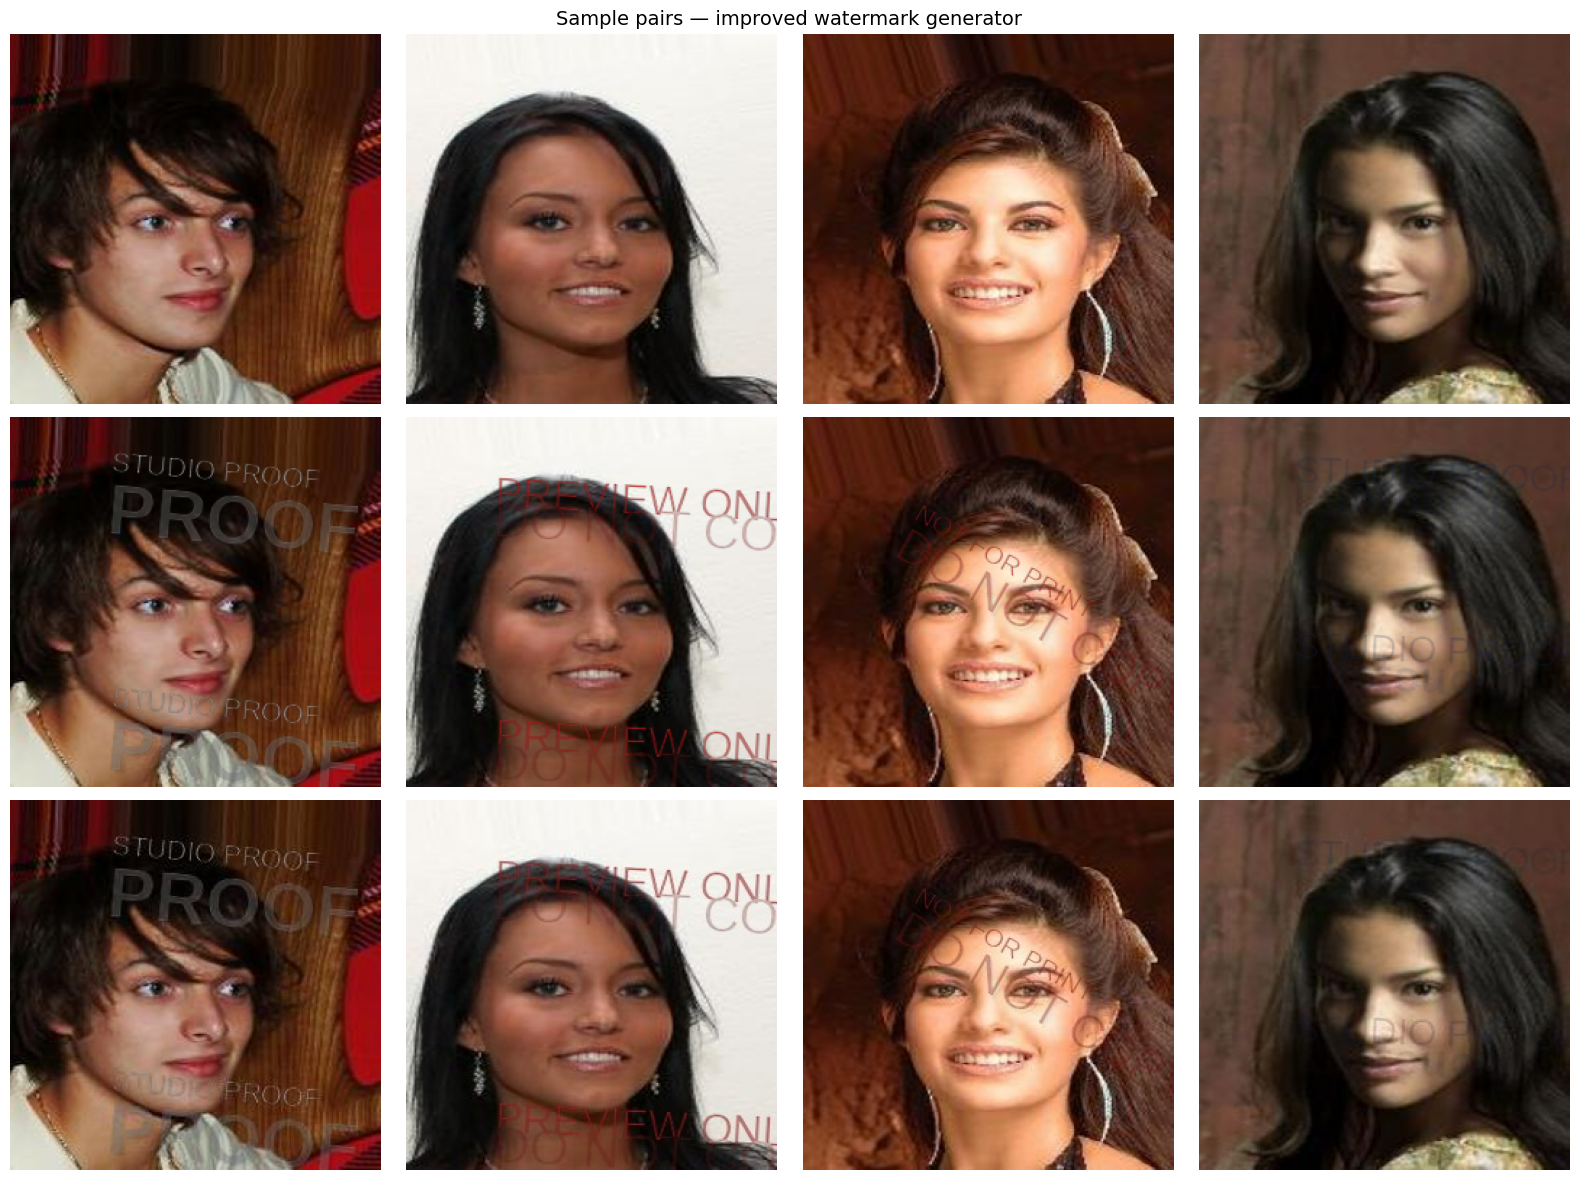

In [ ]:
# ── Visualise a few examples
import matplotlib.pyplot as plt

hf_data  = load_dataset("nielsr/CelebA-faces", split="train", streaming=True)
previews = []
for i, sample in enumerate(hf_data):
    if i >= 4:
        break
    clean = sample["image"].convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
    wm    = add_synthetic_watermark(clean)
    wm_j  = apply_jpeg_noise(wm)
    previews.append((clean, wm, wm_j))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
row_labels = ["Clean", "Watermarked", "+ JPEG noise"]
for col, (clean, wm, wm_j) in enumerate(previews):
    for row, img in enumerate([clean, wm, wm_j]):
        axes[row][col].imshow(img)
        axes[row][col].axis("off")
        if col == 0:
            axes[row][col].set_ylabel(row_labels[row], fontsize=12)

plt.suptitle("Sample pairs — improved watermark generator", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── Generate all pairs
hf_data = load_dataset("nielsr/CelebA-faces", split="train", streaming=True)

print(f"Generating {MAX_SAMPLES} pairs at {IMAGE_SIZE}×{IMAGE_SIZE}...")

for i, sample in enumerate(tqdm(hf_data, total=MAX_SAMPLES)):
    if i >= MAX_SAMPLES:
        break

    split = "train" if i < TRAIN_SPLIT else "val"

    clean_img = sample["image"].convert("RGB").resize(
        (IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS
    )
    wm_img = add_synthetic_watermark(clean_img)
    wm_img = apply_jpeg_noise(wm_img)     # ← JPEG artifact on watermarked only

    clean_img.save(os.path.join(SAVE_ROOT, split, "clean",       f"{i:05d}.png"))
    wm_img.save(   os.path.join(SAVE_ROOT, split, "watermarked", f"{i:05d}.png"))

n_train = len(os.listdir(os.path.join(SAVE_ROOT, "train", "clean")))
n_val   = len(os.listdir(os.path.join(SAVE_ROOT, "val",   "clean")))
print(f"Done — train: {n_train}, val: {n_val}")

Generating 5000 pairs at 256×256...


100%|██████████| 5000/5000 [04:47<00:00, 17.42it/s]

Done — train: 4000, val: 1000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


REAL_PHOTOS_DIR = "/content/drive/MyDrive/Stat Assignments/Project/Part 1/Des Evans "
real_paths = []

if os.path.exists(REAL_PHOTOS_DIR):
    real_paths = [
        os.path.join(REAL_PHOTOS_DIR, f)
        for f in os.listdir(REAL_PHOTOS_DIR)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]
    print(f"Found {len(real_paths)} real photos — will copy to val split.")

    real_val_dir = os.path.join(SAVE_ROOT, "val", "real")
    os.makedirs(real_val_dir, exist_ok=True)

    for j, src in enumerate(real_paths):
        img = Image.open(src).convert("RGB").resize(
            (IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS
        )
        img.save(os.path.join(real_val_dir, f"real_{j:04d}.png"))

    print(f"Saved {len(real_paths)} real photos → {real_val_dir}")
else:
    print("Real photos directory not found — skipping. "
          "Update REAL_PHOTOS_DIR above to add them.")

Found 8 real photos — will copy to val split.
Saved 8 real photos → watermark_dataset_v2/val/real


In [ ]:
# ── Upload to Hugging Face
login()
api = HfApi()

api.create_repo(
    repo_id=REPO_ID,
    repo_type="dataset",
    exist_ok=True,
    private=False
)

def image_to_bytes(path):
    with open(path, "rb") as f:
        return f.read()

for split_name, split_count in [("train", TRAIN_SPLIT), ("val", VAL_SPLIT)]:
    clean_dir = os.path.join(SAVE_ROOT, split_name, "clean")
    wm_dir    = os.path.join(SAVE_ROOT, split_name, "watermarked")
    files     = sorted(os.listdir(clean_dir))

    for start in range(0, len(files), BATCH_SIZE_UPLOAD):
        end   = min(start + BATCH_SIZE_UPLOAD, len(files))
        batch = files[start:end]

        rows = []
        for fname in tqdm(batch, desc=f"{split_name} {start}–{end}"):
            idx = int(os.path.splitext(fname)[0])
            rows.append({
                "pair_id":           idx,
                "clean_image":       image_to_bytes(os.path.join(clean_dir, fname)),
                "watermarked_image": image_to_bytes(os.path.join(wm_dir,   fname)),
            })

        if os.path.exists(TEMP_DIR):
            shutil.rmtree(TEMP_DIR)
        os.makedirs(TEMP_DIR)

        parquet_name = f"{split_name}-{start:05d}-of-{len(files):05d}.parquet"
        pd.DataFrame(rows).to_parquet(os.path.join(TEMP_DIR, parquet_name), index=False)

        api.upload_folder(
            folder_path=TEMP_DIR,
            repo_id=REPO_ID,
            repo_type="dataset",
            path_in_repo=f"data/{split_name}",
            commit_message=f"Upload {split_name} batch {start}–{end}"
        )
        shutil.rmtree(TEMP_DIR)

print("Upload complete.")
print(f"https://huggingface.co/datasets/{REPO_ID}")

train 0–500: 100%|██████████| 500/500 [00:00<00:00, 6179.89it/s]


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...in-00000-of-04000.parquet:   1%|1         | 1.05MB / 85.0MB            

train 500–1000: 100%|██████████| 500/500 [00:00<00:00, 12811.81it/s]


...

val 500–1000: 100%|██████████| 500/500 [00:00<00:00, 12755.08it/s]


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...al-00500-of-01000.parquet:   4%|4         | 3.67MB / 85.6MB            

Upload complete.
https://huggingface.co/datasets/GeraldNdawula/Watermark_Dataset_v2
